# 03 · Grafos de navegación — IVR Alkosto

Toma `df_aristas` y `df_resumen` (salidas de `02_segmentacion.ipynb`) y dibuja el grafo
dirigido de navegación con `graphviz`, igual que `02_Grafos.ipynb` de 2024, pero con dos
diferencias:
- Lee directamente los parquet del pipeline nuevo -- no hace falta generar un Excel filtrado
  por escenario a mano.
- El filtro por escenario (`ESCENARIO`, celda de parámetros) reemplaza el "cambiar la ruta y
  volver a correr" de 2024: se filtra `df_aristas` por `id_conversacion` usando `escenario` de
  `df_resumen` antes de agrupar.

**Entradas:** `df_aristas_<periodo>.parquet`, `df_resumen_<periodo>.parquet`

**Salida:** `.gv` / `.gv.pdf` del grafo (todo el IVR, o un escenario específico).

In [ ]:
import graphviz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

### Parámetros

`ESCENARIO = None` grafica el IVR completo. Para un escenario puntual, usa exactamente el
texto que aparece en `df_resumen["escenario"]` (ej. `"Garantias y devoluciones"`,
`"Entrega y Otros Tramites"`, `"Existencia de producto"`...) -- corre la celda de abajo para
ver las opciones disponibles antes de fijar el valor.

In [ ]:
FECHA_INICIO = "2026-06-01"
FECHA_FIN = "2026-06-30"
ESCENARIO = None  # ej. "Garantias y devoluciones" -- None = todo el IVR

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
SEG_DIR = DATA_DIR / "02_segmentacion"
GRAFOS_DIR = DATA_DIR / "03_grafos"
GRAFOS_DIR.mkdir(parents=True, exist_ok=True)

IN_ARISTAS_PATH = SEG_DIR / f"df_aristas_{FECHA_INICIO}_{FECHA_FIN}.parquet"
IN_RESUMEN_PATH = SEG_DIR / f"df_resumen_{FECHA_INICIO}_{FECHA_FIN}.parquet"

for p in (IN_ARISTAS_PATH, IN_RESUMEN_PATH):
    assert p.exists(), f"No encuentro {p} -- corre primero 02_segmentacion.ipynb"

In [ ]:
df_aristas = pd.read_parquet(IN_ARISTAS_PATH)
df_resumen = pd.read_parquet(IN_RESUMEN_PATH)

print(f"df_aristas: {df_aristas.shape}")
df_resumen["escenario"].value_counts()

df_aristas: (818010, 6)


escenario
No llegó al menú principal         35807
Entrega y Otros Tramites           21362
Garantias y devoluciones           18507
Información general                10510
Existencia de producto              7381
Agendar servicio de instalación     4101
Repetir informacion                 2960
Transferencia Alkosto - Tuya        2939
No input                            1387
No match                             545
Name: count, dtype: int64

### Filtrar por escenario (si aplica) y calcular frecuencia de cada arista

La frecuencia cuenta **ocurrencias del par (origen, destino)**, no conversaciones únicas --
si una llamada pasa dos veces por el mismo par (ej. "Repetir informacion"), cuenta dos veces.
Es la misma lógica que usaba `02_Grafos.ipynb` en 2024 (`groupby().count()`).

In [ ]:
if ESCENARIO is not None:
    ids_escenario = df_resumen.loc[df_resumen["escenario"] == ESCENARIO, "id_conversacion"]
    assert len(ids_escenario) > 0, f"'{ESCENARIO}' no aparece en df_resumen['escenario']"
    df_aristas_filtrado = df_aristas[df_aristas["id_conversacion"].isin(ids_escenario)]
else:
    df_aristas_filtrado = df_aristas

resultado = (
    df_aristas_filtrado
    .groupby(["op_text", "op_text_final"])
    .agg(frecuencia=("id_conversacion", "count"))
    .sort_values("frecuencia", ascending=False)
    .reset_index()
)

print(f"Escenario: {ESCENARIO or 'TODO EL IVR'}")
print(f"{len(resultado)} aristas distintas, {df_aristas_filtrado['id_conversacion'].nunique():,} conversaciones")
resultado.head(10)

Escenario: TODO EL IVR
755 aristas distintas, 97,151 conversaciones


,op_text,op_text_final,frecuencia
0,Inicio IVR,Usuario_Identificado_Con_Ani,31034
1,Bienvenida encuesta SAC,Primera pregunta SAC,29964
2,Solicitud_Para_mi,Menu principal,26942
3,Usuario_Identificado_Con_Ani,Solicitud_Para_mi,24868
4,Menu principal,Entrega y Otros Tramites,22684
5,Menu principal,Garantias y devoluciones,20277
6,Finalización por fin de flujo,final,18541
7,Entrega y Otros Tramites,Estado de entrega,16043
8,Habeas data positivo,Menu principal,15900
9,Inicio IVR,Menu principal,15458


### Construir el grafo

Mismo esquema de color que 2024: escala `YlOrRd` normalizada en log sobre el volumen total
que recibe cada nodo, para que los puntos más transitados se vean "más calientes".

In [ ]:
import os
os.environ["PATH"] = r"C:\Program Files (x86)\Graphviz\bin" + os.pathsep + os.environ["PATH"]
#Para agregar al path de Windows (PowerShell) y que Graphviz funcione en Jupyter Notebook, descomenta estas líneas:
#$env:PATH = "C:\Program Files (x86)\Graphviz\bin;$env:PATH"
#Test-Path "C:\Program Files (x86)\Graphviz\bin\dot.exe"

Guardado: data\03_grafos\grafo_todo_ivr_2026-06-01_2026-06-30.gv.pdf


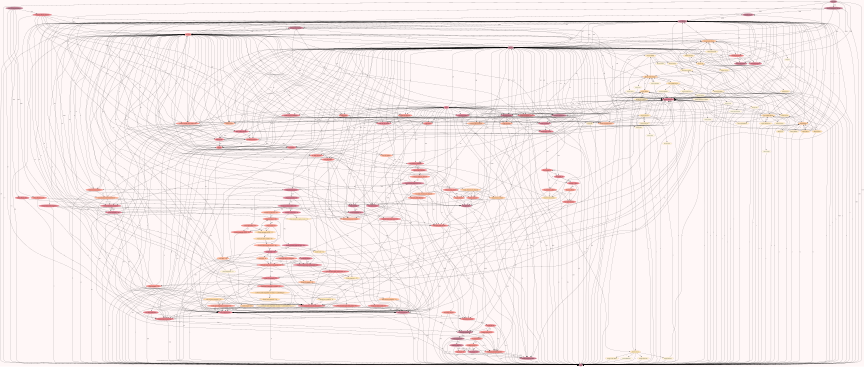

In [ ]:
cmap = plt.colormaps["YlOrRd"]
norm = mcolors.Normalize(
    vmin=np.log(resultado["frecuencia"].min()),
    vmax=np.log(resultado["frecuencia"].max()),
)

nombre_archivo = f"grafo_{(ESCENARIO or 'todo_ivr').lower().replace(' ', '_')}_{FECHA_INICIO}_{FECHA_FIN}"

u = graphviz.Digraph(
    "ivr",
    filename=str(GRAFOS_DIR / f"{nombre_archivo}.gv"),
    node_attr={"color": "#bf7f92", "style": "filled"},
)
u.attr(size="12,12")
u.attr(bgcolor="#fff7f7")

for _, fila in resultado.iterrows():
    u.edge(fila["op_text"], fila["op_text_final"], label=str(fila["frecuencia"]))

for nodo_destino in resultado["op_text_final"].unique():
    volumen = resultado.loc[resultado["op_text_final"] == nodo_destino, "frecuencia"].sum()
    color = mcolors.to_hex(cmap(norm(np.log(volumen))))
    u.node(nodo_destino, fillcolor=color + "80")

u.render(cleanup=True)  # genera el .pdf sin intentar abrirlo (usa u.view() si prefieres que se abra)
print(f"Guardado: {GRAFOS_DIR / (nombre_archivo + '.gv.pdf')}")
u